In [1]:
# function definitions moved to functions.py


# Top-NMF: Appendix 2

# Import Libraries

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from sklearn.decomposition._nmf import _initialize_nmf
from scipy.interpolate import make_interp_spline
from tqdm.notebook import tqdm

from TopNMF import *
from cubical_complex import *

device = 'cpu'

2025-12-08 05:40:13.256075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765140013.267234  129359 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765140013.270722  129359 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-08 05:40:13.282238: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Generate Synthetic Signals

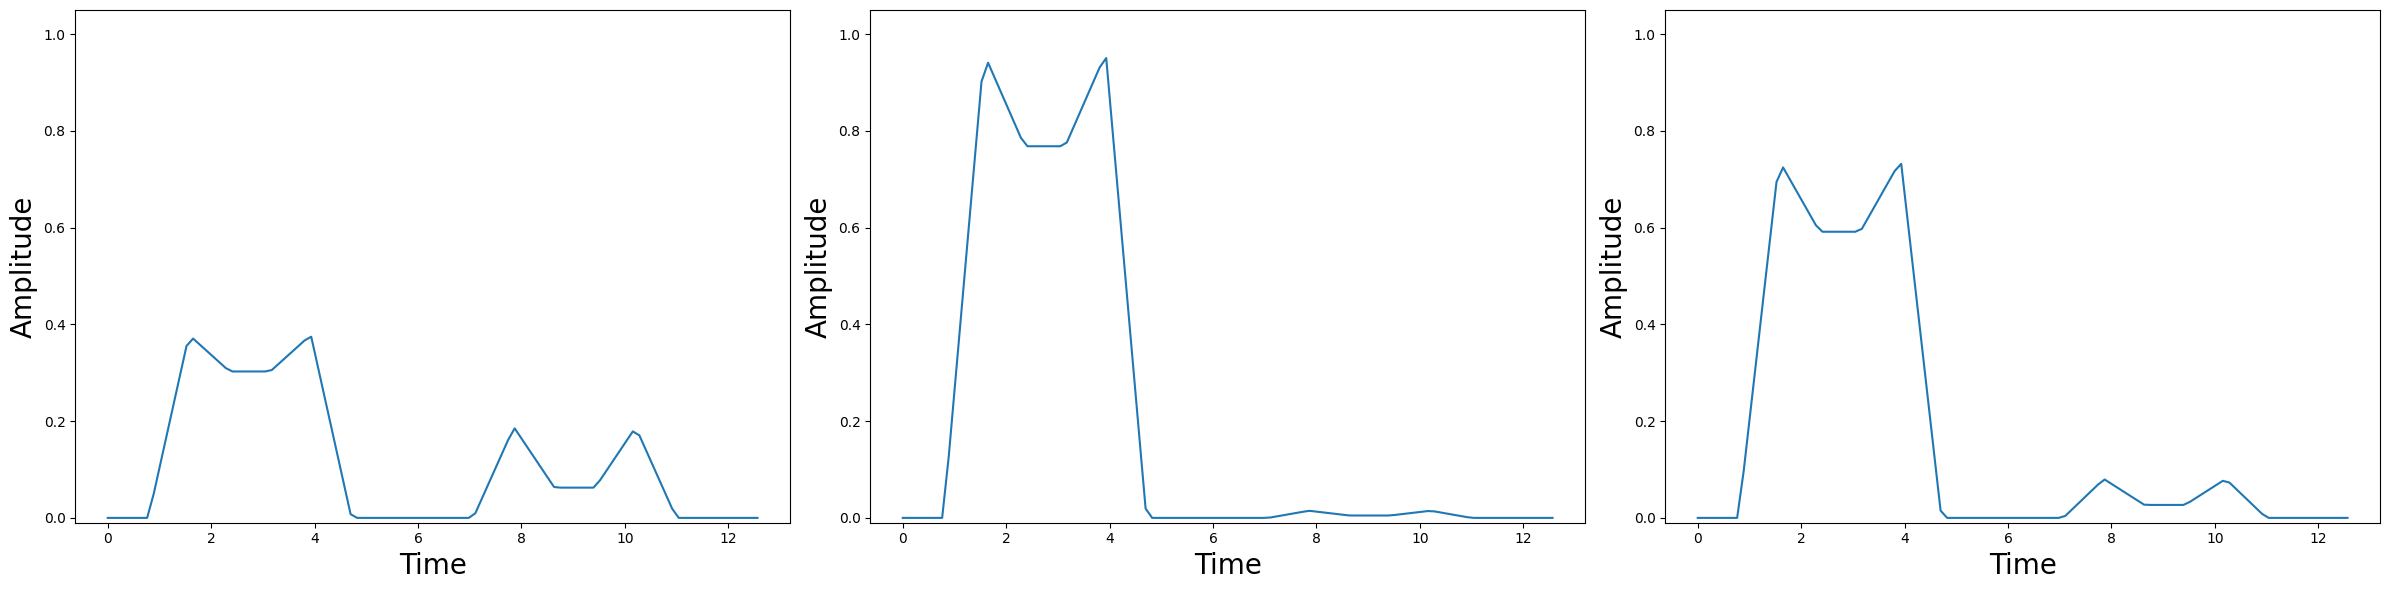

In [ ]:
# Generate base signals and mix to form dataset

x_anchor = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0])
y_anchor = np.array([0.0, 0.0, 1.0, 0.8, 0.8, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# First base shape
a_smooth = np.linspace(x_anchor.min(), x_anchor.max(), 100)
spline = make_interp_spline(x_anchor, y_anchor, k=1)
y_smooth_1 = spline(a_smooth)
y_smooth_1 /= np.max(y_smooth_1)



# Second base shape
y_anchor = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.1, 0.1, 0.3, 0.0, 0.0, 0.0])
spline = make_interp_spline(x_anchor, y_anchor, k=1)
y_smooth_2 = spline(a_smooth)



# Mix two shapes to create dataset
np.random.seed(42)
rand = np.random.rand(3)

# Fixed dataset (no randomness)
X_list = [
    y_smooth_1,
    y_smooth_2,
    y_smooth_1 + y_smooth_2
]

# Plot
t = np.linspace(0, 4 * np.pi, 100)
plt.figure(figsize=(24, 6))

for i, signal in enumerate(X_list):
    plt.subplot(1, len(X_list), i + 1)
    plt.plot(t, signal)
    plt.xlabel("Time", size=20)
    plt.ylabel("Amplitude", size=20)
    plt.ylim(-0.01, 1.05)

plt.tight_layout()
plt.show()

X = np.array(X_list)

# Run Top-NMF

  0%|          | 0/30000 [00:00<?, ?it/s]

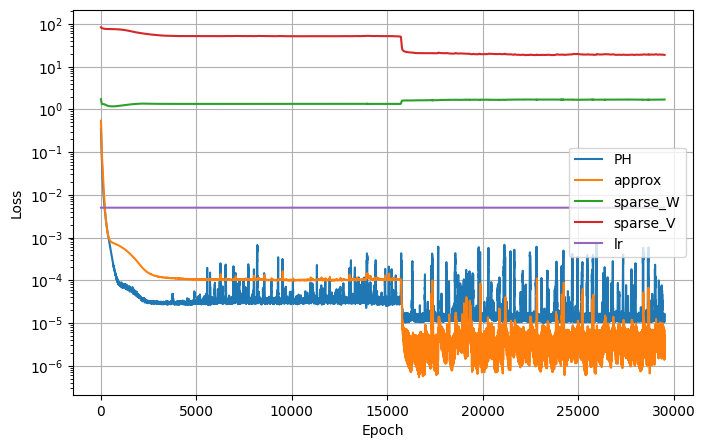

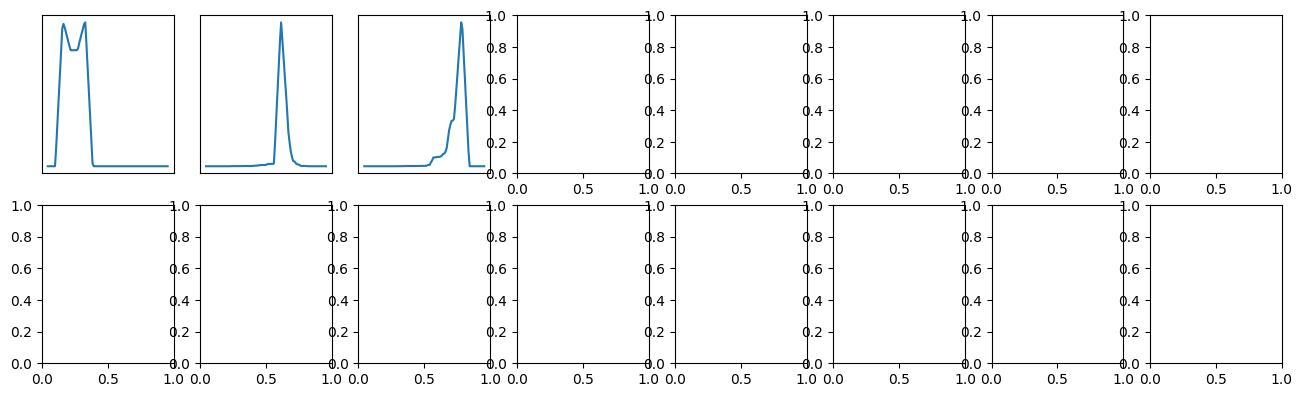

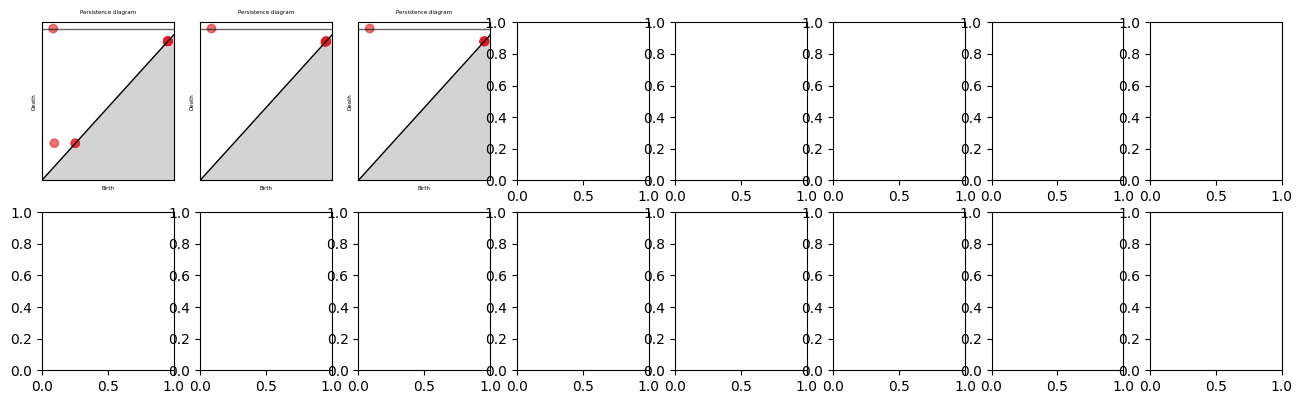

target L1/L2 ratio 0


In [28]:
# fit
lr = 0.005 # learning rate for gradient descent  (Adam: 0.1, SGD: 5)
target_sparsity = None # set to None, if you are not using
epsilon = 1e-10 # for numerical stability
PHmode = "V" # T or V construction
superlevel = True

## specify target PH (or set to None for sparsity)
target_PH = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]


gd_iter = 1 # gradient descent update per iteration
mu_iter = 0 # multiplicative update per iteration
W_iter = 1 # W update per multiplicative update iteration
start_epoch_sparsify =0 # from this epoch, start sprase_opt
start_epoch_topological=0 # from this epoch, start loss_PH optimisation
show_plots = ["loss","basis","PH"] # ["loss","basis","PH"]

lambda_apx = 1.0 # (we do not have to use for mu) reconstruction loss in gradient descent
lambda_spa_V = 0.0 # (we do not have to use for mu)
lambda_spa_W = 0.0 # (we do not have to use for mu)
lambda_top = 0.5 # 0.5 # top-NMF   # around 0.001
weight_decay = 0.0

lambda_tv = 0.0


init_optimizer = True

normalise = True


## filtration
cpx = CubicalComplex(superlevel=superlevel,dim=len(data_dims),mode=PHmode)


##
n_row, n_col = 2 , 8 # display
n_iterations = 30000
PH_dims = [0] # which dim to look at in PH
tol = 1e-4 # early stopping
tol_count = 30000 # early stopping
disp_interval = 10

loss_fn = torch.nn.MSELoss() # approximation error
# loss_fn = torch.nn.HuberLoss() # approximation error



##
X = torch.as_tensor(X.reshape(n_samples,-1), dtype=torch.float, device=device)
W = torch.tensor(W, dtype=torch.float, device=device, requires_grad=True)
V = torch.tensor(V, dtype=torch.float, device=device, requires_grad=True)
Vns = []
if normalise:
    with torch.no_grad():
        # V /= (torch.norm(V, p=2, dim=1, keepdim=True)+epsilon)
        # V /= torch.max(V, dim=1).values.unsqueeze(1)
        # W /= (torch.norm(W, p=1, dim=1, keepdim=True)+epsilon)

        normal_value = torch.max(V, dim=1).values.unsqueeze(1)
        V /= normal_value
        # W *= normal_value.view(1, -1)


## initialise optimiser
if init_optimizer:
    opt = torch.optim.AdamW([W, V], lr=lr, weight_decay=weight_decay) # SGD, Adam, AdamW(weight decay for sparsity), or NAdam?
    # opt = torch.optim.Adam([W, V], lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.9, patience=1500000)



## optimisation iteration
progress = tqdm(range(n_iterations))
prev_loss = np.inf
count = 0
losses = {"PH":[], "approx":[], "sparse_W":[], "sparse_V":[], "lr":[]}

if target_sparsity is not None and target_sparsity > 0:
    target_L1 = np.sqrt(V.shape[1]) - target_sparsity * (np.sqrt(V.shape[1]) - 1)
else:
    target_L1 = 0

# prepare figures
if "loss" in show_plots:
    fig_L,axs_L = plt.subplots(1,1,figsize=(8,5))
    disp_L = display(fig_L,display_id=True)
if "basis" in show_plots:
    fig_V,axs_V = plt.subplots(n_row,n_col, figsize=(2. * n_col, 2.26 * n_row))
    disp_V = display(fig_V,display_id=True)
if "PH" in show_plots:
    fig_P,axs_P = plt.subplots(n_row,n_col, figsize=(2. * n_col, 2.26 * n_row))
    disp_P = display(fig_P,display_id=True)





    

## main iteration
for epoch in progress:
    # multiplicative update
    with torch.no_grad():
        for _ in range(mu_iter):
            #update V
            if target_sparsity is None or epoch<start_epoch_sparsify:
                W_TX = W.T @ X
                W_TWV = W.T @ W @ V + epsilon
                V *= W_TX / W_TWV
            else:
                update_V(X, W, V, target_L1) # update "V" with target sparsity

            #update W
            for _ in range(W_iter):
                XV_T = X @ V.T
                WVV_T = W @ V @ V.T + epsilon
                W *= XV_T / WVV_T

    # gradient descent update
    for _ in range(gd_iter):
        # compute PD of rows of V
        loss_PH=torch.tensor(0., device=device)
        if target_PH is None:
            loss_PH -= n_components
        loss_spa_V=torch.tensor(0., device=device)
        loss_spa_W=torch.tensor(0., device=device)
        sp_score=torch.tensor(0., device=device)
        loss_tv_V = torch.tensor(0., device=device)
        # for j in range(n_components):
        for j in range(n_components):
            v=V[j]
            # PH sparsity
            if lambda_top>0:
                diags = cpx(v.reshape(data_dims))
                if target_PH is None:
                    # PH sparsity
                    PH = torch.cat([diags[dim].diagram for dim in PH_dims])
                    pers1 = torch.diff(PH, dim=1).reshape(-1)                    
                    l1sq = pers1.sum()**2
                    l2sq = pers1.pow(2).sum()
                    loss_PH += (l1sq/(l2sq+epsilon))
                    
                else:
                    # target PH
                    if epoch>=start_epoch_topological:
                        for dim in PH_dims:
                            if dim==0:
                                remove_longest_D1=True
                            else:
                                remove_longest_D1=False    
                            loss_PH += weighted_persistence_loss(diags[dim].diagram, remove_longest=remove_longest_D1)

            loss_tv_V += total_variation(v)
            
            # sparsity
            if target_sparsity is not None:
                loss_spa_V += (sparsity_score(v)-target_sparsity)**2
            else:
                #loss_spa += (1-sparsity_score(v))
                loss_spa_V += (v.abs().sum())**2/(v**2).sum()
            sp_score += sparsity_score(v)

        
        # loss_spa_W = (W.abs().sum())**2/(W**2).sum()  
        # row-wise
        # for j in range(n_samples):
        #     w=W[j]
        #     loss_spa_W += (w.abs().sum())**2/(w**2).sum()

        loss_spa_W = torch.sum(torch.sum(torch.abs(W), dim=1)**2/torch.sum(W**2, dim=1))    

        loss_spa_V /= n_components
        loss_spa_W /= n_components
        loss_PH /= n_components
        sp_score /= n_components
        loss_apx = loss_fn(torch.mm(W, V),X)
    
        # gradient descent
        loss = lambda_top * loss_PH + lambda_spa_V * loss_spa_V + lambda_spa_W * loss_spa_W +  lambda_apx * loss_apx + lambda_tv * loss_tv_V
        opt.zero_grad()
        loss.backward()
        #vv = V.clone().detach()
        opt.step()
        scheduler.step(loss)
        losses["PH"].append(loss_PH.item())
        losses["approx"].append(loss_apx.item())
        losses["sparse_V"].append(loss_spa_V.item())
        losses["sparse_W"].append(loss_spa_W.item())
        losses["lr"].append(scheduler.get_last_lr()[0])

    # Enforce nonnegativity by clamping
    with torch.no_grad():
        W.clamp_(min=0)
        V.clamp_(min=0)
        if normalise:
            # V /= (torch.norm(V, p=2, dim=1, keepdim=True)+epsilon)
            # V /= torch.max(V, dim=1).values.unsqueeze(1)
            # W /= (torch.norm(W, p=1, dim=1, keepdim=True)+epsilon)
    
    
            normal_value = torch.max(V, dim=1).values.unsqueeze(1)
            V /= normal_value
            # W *= normal_value.view(1, -1)
    # display
    progress.set_postfix(loss=f'PH: {loss_PH.item():.08f},sparsity: {sp_score.item():.08f},approx: {loss_apx.item():.08f}')
    if epoch%disp_interval==0:
        Vns.append(V.detach().cpu().numpy().copy())
        #clear_output(wait=True)
        
        # for key in losses.keys():
        #     line[key].set_xdata(range(len(losses[key])))
        #     line[key].set_ydata(losses[key])
        if "loss" in show_plots:
            plot_loss(losses,ax=axs_L)
            disp_L.update(fig_L)
        if "basis" in show_plots:
            plot_gallery(Vns[-1].reshape(-1,*data_dims),title="basis",n_row=n_row, n_col = n_col, axs=axs_V)
            disp_V.update(fig_V)
        if "PH" in show_plots:
            plot_PD(Vns[-1].reshape(-1,*data_dims),n_row=n_row, n_col = n_col, axs=axs_P,PHmode = PHmode, superlevel=superlevel)
            disp_P.update(fig_P)
        #plt.show()
        #display(plt.gcf())
        disp_interval = int(1.2*disp_interval) # increase interval

    # early stopping
    current = lambda_top * loss_PH + lambda_spa_V * loss_spa_V + lambda_spa_W * loss_spa_W + loss_apx
    if (prev_loss-current)<tol:
      count += 1
      if count > tol_count:
        break
    else:
      prev_loss = current.item()
      count = 0

# check norm
plt.close('all')
print("target L1/L2 ratio",target_L1)
#print(np.linalg.norm(V.detach(),axis=1))

# Display Learned Basis Vectors (Top-NMF)

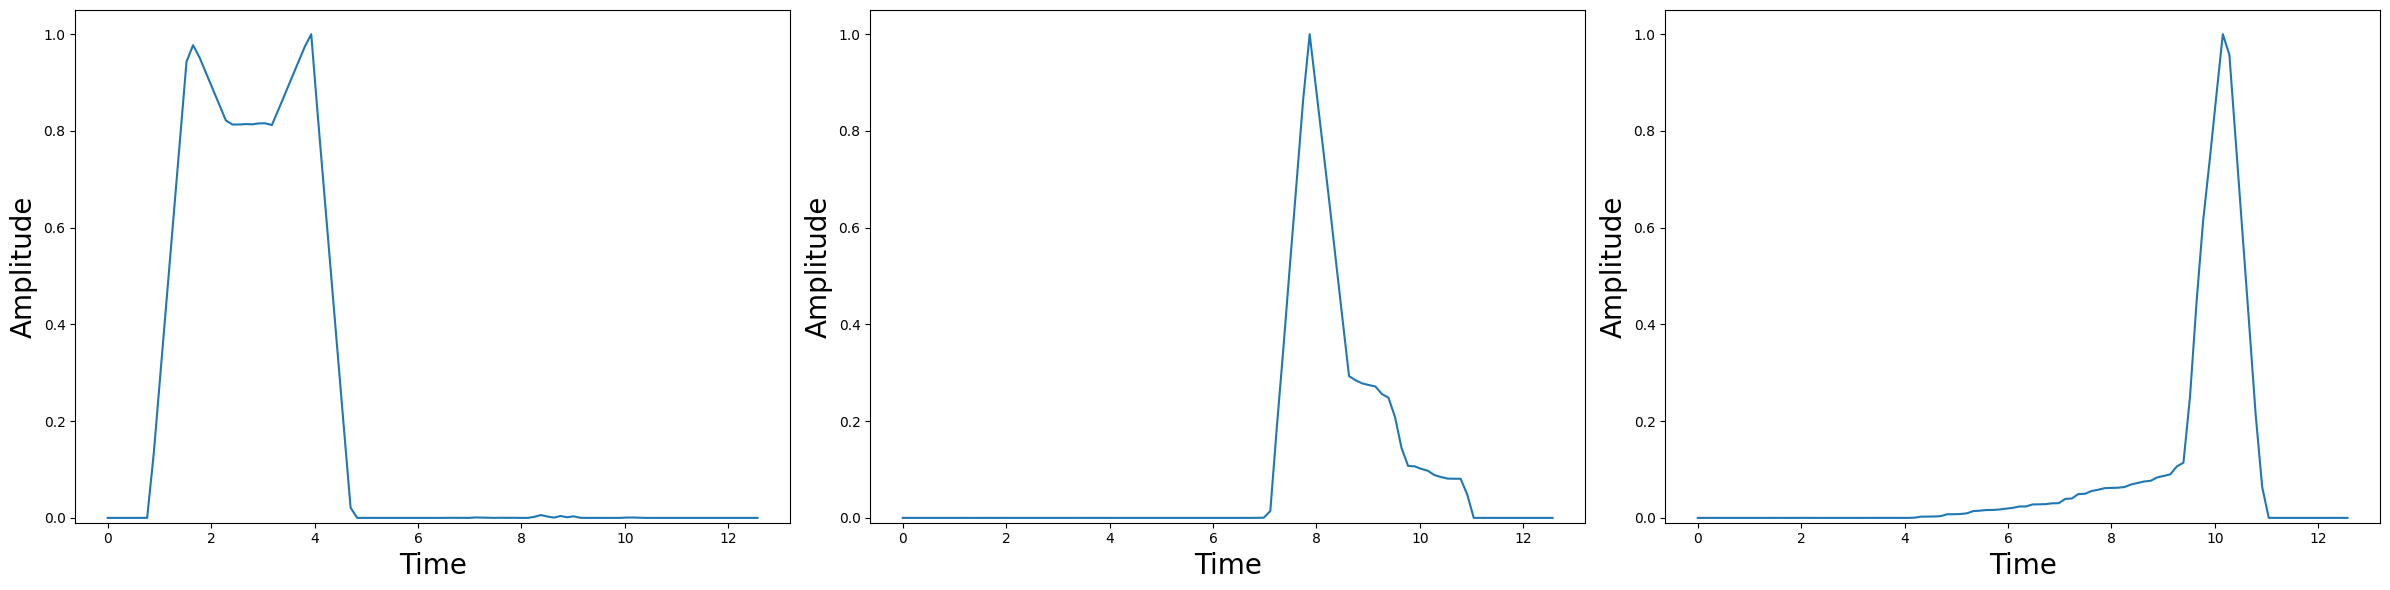

In [29]:
t = np.linspace(0, 4*np.pi, 100)

plt.figure(figsize=(24, 6))
for i in range(len(Vns[-1])):
    plt.subplot(1,len(Vns[-1]), i + 1)
    plt.plot(t, Vns[-3][i])
    plt.xlabel("Time", size=20)
    plt.ylabel("Amplitude", size=20)
    plt.ylim(-0.01, 1.05)

plt.tight_layout()


In [6]:
# Generate base signals and mix to form dataset
x_anchor = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0])
y_anchor = np.array([0.0, 0.0, 1.0, 0.8, 0.8, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
# First base shape
a_smooth = np.linspace(x_anchor.min(), x_anchor.max(), 100)
spline = make_interp_spline(x_anchor, y_anchor, k=1)
y_smooth_1 = spline(a_smooth)
y_smooth_1 /= np.max(y_smooth_1)

# Second base shape
y_anchor = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.1, 0.1, 0.3, 0.0, 0.0, 0.0])
spline = make_interp_spline(x_anchor, y_anchor, k=1)
y_smooth_2 = spline(a_smooth)

# Mix two shapes to create dataset
rand = np.random.rand(3)
X_list = []
for r in rand:
    X_list.append(r * y_smooth_1 + (1 - r) * y_smooth_2)


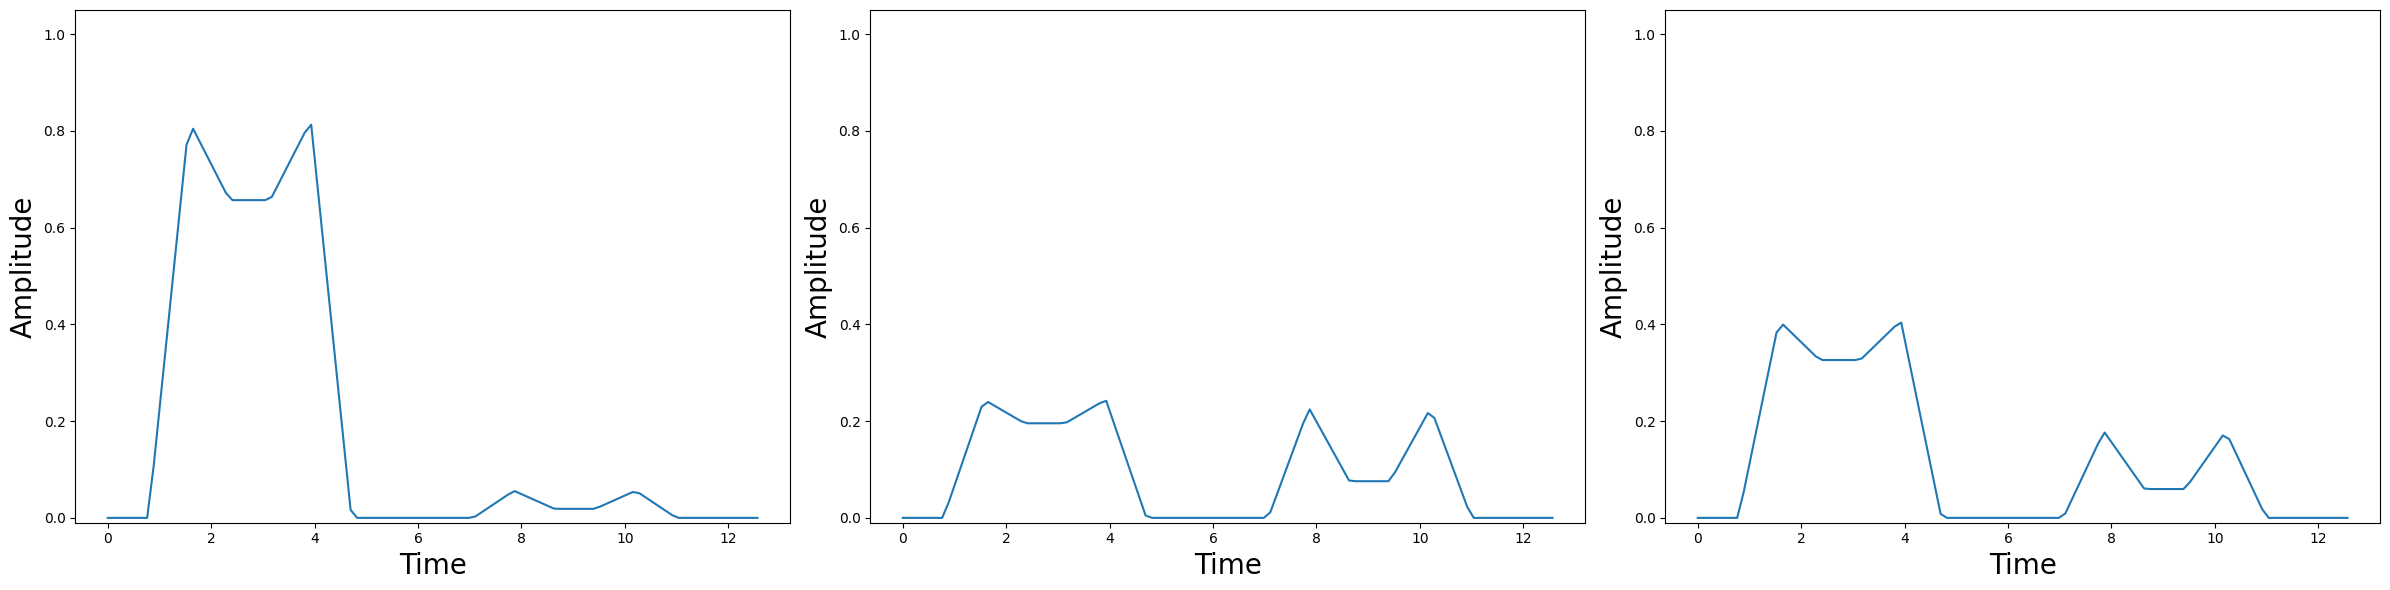

In [7]:
t = np.linspace(0, 4*np.pi, 100)
plt.figure(figsize=(24, 6))
for i, signal in enumerate(X_list):
    plt.subplot(1, len(X_list), i + 1)
    plt.plot(t, signal)
    plt.xlabel("Time", size=20)
    plt.ylabel("Amplitude", size=20)
    plt.ylim(-0.01, 1.05)

plt.tight_layout()


(3, 100) (3, 3) (3, 100)


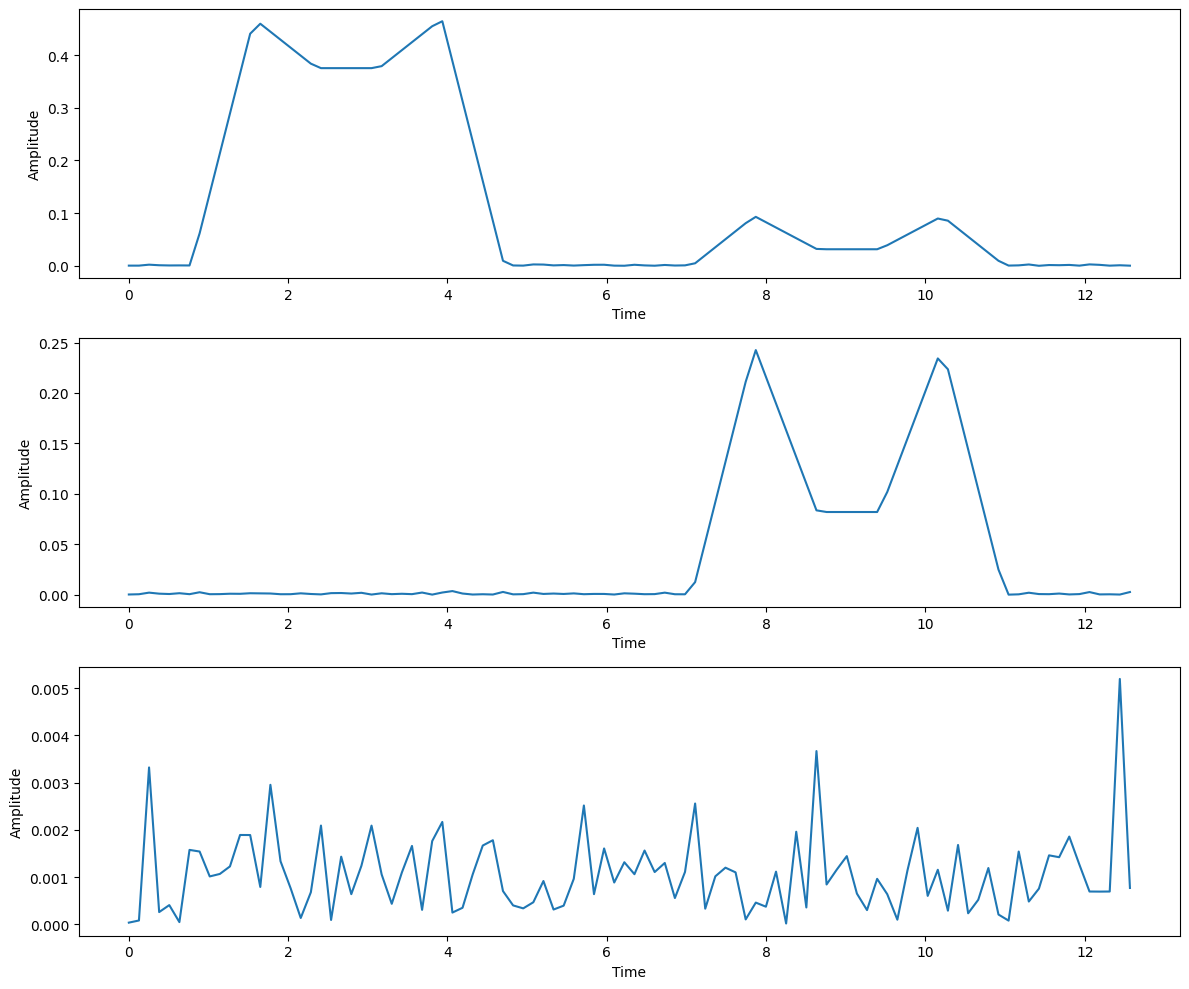

In [8]:
X = np.array(X_list)
n_components = 3

n_samples = X.shape[0]
data_dims = X.shape[1:]
n_features = X[0].size

W, V = _initialize_nmf(X.copy().reshape(n_samples, -1), n_components=n_components, init='nndsvdar', random_state=42)

print(X.shape, W.shape, V.shape)

plt.figure(figsize=(12, 10))
for i in range(V.shape[0]):
    plt.subplot(V.shape[0], 1, i + 1)
    plt.plot(t, V[i])
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


  0%|          | 0/30000 [00:00<?, ?it/s]

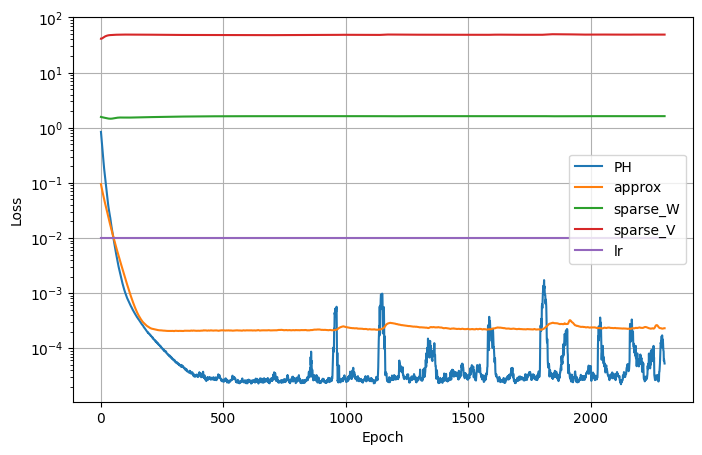

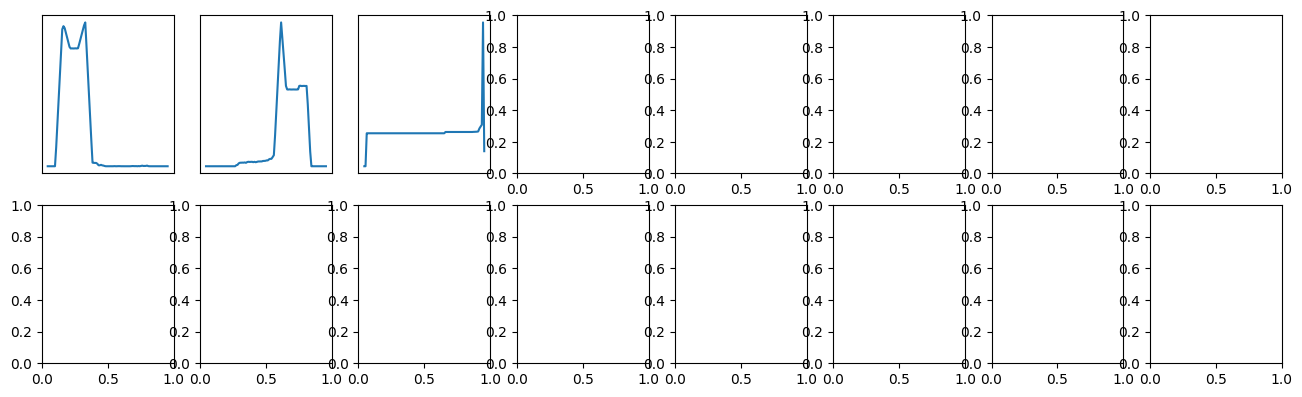

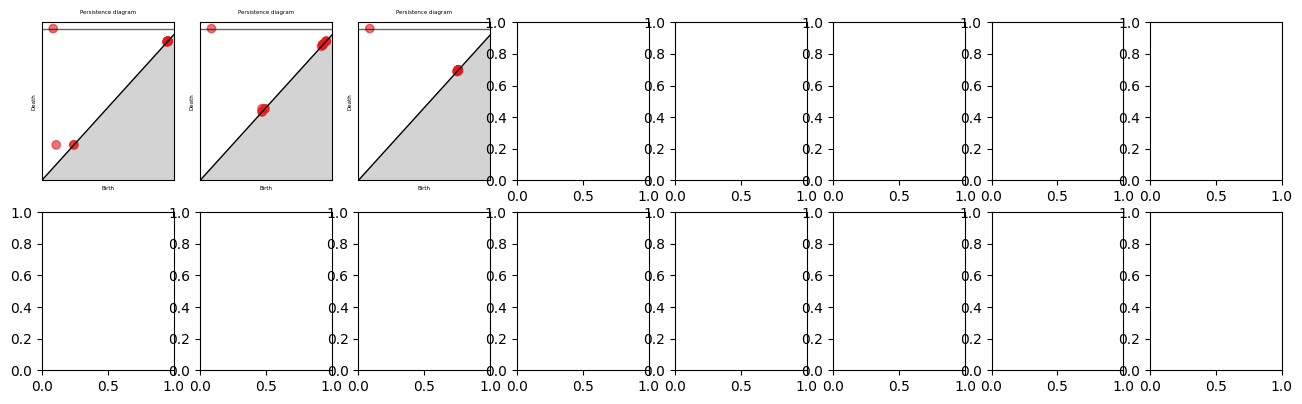

KeyboardInterrupt: 

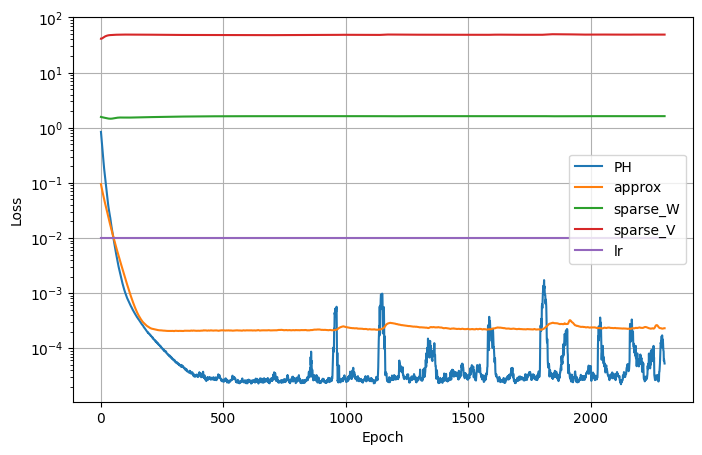

Error in callback <function flush_figures at 0x77d9ccdf1c60> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



In [9]:
# fit
lr = 0.01 # learning rate for gradient descent  (Adam: 0.1, SGD: 5)
target_sparsity = None # set to None, if you are not using
epsilon = 1e-10 # for numerical stability
PHmode = "V" # T or V construction
superlevel = True

## specify target PH (or set to None for sparsity)
target_PH = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]


gd_iter = 1 # gradient descent update per iteration
mu_iter = 0 # multiplicative update per iteration
W_iter = 1 # W update per multiplicative update iteration
start_epoch_sparsify =0 # from this epoch, start sprase_opt
start_epoch_topological=0 # from this epoch, start loss_PH optimisation
show_plots = ["loss","basis","PH"] # ["loss","basis","PH"]

lambda_apx = 1.0 # (we do not have to use for mu) reconstruction loss in gradient descent
lambda_spa_V = 0.0 # (we do not have to use for mu)
lambda_spa_W = 0.0 # (we do not have to use for mu)
lambda_top = 1.0 # 0.5 # top-NMF   # around 0.001
weight_decay = 0.0

lambda_tv = 0.0


init_optimizer = True

normalise = True


## filtration
cpx = CubicalComplex(superlevel=superlevel,dim=len(data_dims),mode=PHmode)


##
n_row, n_col = 2 , 8 # display
n_iterations = 30000
PH_dims = [0] # which dim to look at in PH
tol = 1e-4 # early stopping
tol_count = 30000 # early stopping
disp_interval = 10

loss_fn = torch.nn.MSELoss() # approximation error
# loss_fn = torch.nn.HuberLoss() # approximation error



##
X = torch.as_tensor(X.reshape(n_samples,-1), dtype=torch.float, device=device)
W = torch.tensor(W, dtype=torch.float, device=device, requires_grad=True)
V = torch.tensor(V, dtype=torch.float, device=device, requires_grad=True)
Vns = []
if normalise:
    with torch.no_grad():
        # V /= (torch.norm(V, p=2, dim=1, keepdim=True)+epsilon)
        # V /= torch.max(V, dim=1).values.unsqueeze(1)
        # W /= (torch.norm(W, p=1, dim=1, keepdim=True)+epsilon)

        normal_value = torch.max(V, dim=1).values.unsqueeze(1)
        V /= normal_value
        # W *= normal_value.view(1, -1)


## initialise optimiser
if init_optimizer:
    opt = torch.optim.AdamW([W, V], lr=lr, weight_decay=weight_decay) # SGD, Adam, AdamW(weight decay for sparsity), or NAdam?
    # opt = torch.optim.Adam([W, V], lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.9, patience=1500000)



## optimisation iteration
progress = tqdm(range(n_iterations))
prev_loss = np.inf
count = 0
losses = {"PH":[], "approx":[], "sparse_W":[], "sparse_V":[], "lr":[]}

if target_sparsity is not None and target_sparsity > 0:
    target_L1 = np.sqrt(V.shape[1]) - target_sparsity * (np.sqrt(V.shape[1]) - 1)
else:
    target_L1 = 0

# prepare figures
if "loss" in show_plots:
    fig_L,axs_L = plt.subplots(1,1,figsize=(8,5))
    disp_L = display(fig_L,display_id=True)
if "basis" in show_plots:
    fig_V,axs_V = plt.subplots(n_row,n_col, figsize=(2. * n_col, 2.26 * n_row))
    disp_V = display(fig_V,display_id=True)
if "PH" in show_plots:
    fig_P,axs_P = plt.subplots(n_row,n_col, figsize=(2. * n_col, 2.26 * n_row))
    disp_P = display(fig_P,display_id=True)





    

## main iteration
for epoch in progress:
    # multiplicative update
    with torch.no_grad():
        for _ in range(mu_iter):
            #update V
            if target_sparsity is None or epoch<start_epoch_sparsify:
                W_TX = W.T @ X
                W_TWV = W.T @ W @ V + epsilon
                V *= W_TX / W_TWV
            else:
                update_V(X, W, V, target_L1) # update "V" with target sparsity

            #update W
            for _ in range(W_iter):
                XV_T = X @ V.T
                WVV_T = W @ V @ V.T + epsilon
                W *= XV_T / WVV_T

    # gradient descent update
    for _ in range(gd_iter):
        # compute PD of rows of V
        loss_PH=torch.tensor(0., device=device)
        if target_PH is None:
            loss_PH -= n_components
        loss_spa_V=torch.tensor(0., device=device)
        loss_spa_W=torch.tensor(0., device=device)
        sp_score=torch.tensor(0., device=device)
        loss_tv_V = torch.tensor(0., device=device)
        # for j in range(n_components):
        for j in range(n_components):
            v=V[j]
            # PH sparsity
            if lambda_top>0:
                diags = cpx(v.reshape(data_dims))
                if target_PH is None:
                    # PH sparsity
                    PH = torch.cat([diags[dim].diagram for dim in PH_dims])
                    pers1 = torch.diff(PH, dim=1).reshape(-1)                    
                    l1sq = pers1.sum()**2
                    l2sq = pers1.pow(2).sum()
                    loss_PH += (l1sq/(l2sq+epsilon))
                    
                else:
                    # target PH
                    if epoch>=start_epoch_topological:
                        for dim in PH_dims:
                            if dim==0:
                                remove_longest_D1=True
                            else:
                                remove_longest_D1=False    
                            loss_PH += weighted_persistence_loss(diags[dim].diagram, remove_longest=remove_longest_D1)

            loss_tv_V += total_variation(v)
            
            # sparsity
            if target_sparsity is not None:
                loss_spa_V += (sparsity_score(v)-target_sparsity)**2
            else:
                #loss_spa += (1-sparsity_score(v))
                loss_spa_V += (v.abs().sum())**2/(v**2).sum()
            sp_score += sparsity_score(v)

        
        # loss_spa_W = (W.abs().sum())**2/(W**2).sum()  
        # row-wise
        # for j in range(n_samples):
        #     w=W[j]
        #     loss_spa_W += (w.abs().sum())**2/(w**2).sum()

        loss_spa_W = torch.sum(torch.sum(torch.abs(W), dim=1)**2/torch.sum(W**2, dim=1))    

        loss_spa_V /= n_components
        loss_spa_W /= n_components
        loss_PH /= n_components
        sp_score /= n_components
        loss_apx = loss_fn(torch.mm(W, V),X)
    
        # gradient descent
        loss = lambda_top * loss_PH + lambda_spa_V * loss_spa_V + lambda_spa_W * loss_spa_W +  lambda_apx * loss_apx + lambda_tv * loss_tv_V
        opt.zero_grad()
        loss.backward()
        #vv = V.clone().detach()
        opt.step()
        scheduler.step(loss)
        losses["PH"].append(loss_PH.item())
        losses["approx"].append(loss_apx.item())
        losses["sparse_V"].append(loss_spa_V.item())
        losses["sparse_W"].append(loss_spa_W.item())
        losses["lr"].append(scheduler.get_last_lr()[0])

    # Enforce nonnegativity by clamping
    with torch.no_grad():
        W.clamp_(min=0)
        V.clamp_(min=0)
        if normalise:
            # V /= (torch.norm(V, p=2, dim=1, keepdim=True)+epsilon)
            # V /= torch.max(V, dim=1).values.unsqueeze(1)
            # W /= (torch.norm(W, p=1, dim=1, keepdim=True)+epsilon)
    
    
            normal_value = torch.max(V, dim=1).values.unsqueeze(1)
            V /= normal_value
            # W *= normal_value.view(1, -1)
    # display
    progress.set_postfix(loss=f'PH: {loss_PH.item():.08f},sparsity: {sp_score.item():.08f},approx: {loss_apx.item():.08f}')
    if epoch%disp_interval==0:
        Vns.append(V.detach().cpu().numpy().copy())
        #clear_output(wait=True)
        
        # for key in losses.keys():
        #     line[key].set_xdata(range(len(losses[key])))
        #     line[key].set_ydata(losses[key])
        if "loss" in show_plots:
            plot_loss(losses,ax=axs_L)
            disp_L.update(fig_L)
        if "basis" in show_plots:
            plot_gallery(Vns[-1].reshape(-1,*data_dims),title="basis",n_row=n_row, n_col = n_col, axs=axs_V)
            disp_V.update(fig_V)
        if "PH" in show_plots:
            plot_PD(Vns[-1].reshape(-1,*data_dims),n_row=n_row, n_col = n_col, axs=axs_P,PHmode = PHmode, superlevel=superlevel)
            disp_P.update(fig_P)
        #plt.show()
        #display(plt.gcf())
        disp_interval = int(1.2*disp_interval) # increase interval

    # early stopping
    current = lambda_top * loss_PH + lambda_spa_V * loss_spa_V + lambda_spa_W * loss_spa_W + loss_apx
    if (prev_loss-current)<tol:
      count += 1
      if count > tol_count:
        break
    else:
      prev_loss = current.item()
      count = 0

# check norm
plt.close('all')
print("target L1/L2 ratio",target_L1)
#print(np.linalg.norm(V.detach(),axis=1))

In [ ]:
t = np.linspace(0, 4*np.pi, 100)

plt.figure(figsize=(24, 6))
for i in range(len(Vns[-1])):
    plt.subplot(1,len(Vns[-1]), i + 1)
    plt.plot(t, Vns[-1][i])
    plt.xlabel("Time", size=20)
    plt.ylabel("Amplitude", size=20)
    plt.ylim(-0.01, 1.05)

plt.tight_layout()


In [ ]:
plot_gallery((W@V).detach().numpy().reshape(-1,*data_dims),n_row=1, n_col = 3)